# 05 · PCA — Análisis de Componentes Principales
**Tesis:** Medición del ciclo financiero en Perú mediante técnicas de reducción dimensional y machine learning

**Responsabilidad única de este notebook:** ajustar PCA sobre las dos versiones
estandarizadas del dataset (niveles vs. transformado) y comparar resultados.
No modifica ningún archivo de `data/processed/` -- solo lee.

**Entradas (solo lectura):**
- `data/processed/dataset_niveles_estandarizado_trimestral.csv`
- `data/processed/dataset_estandarizado_trimestral.csv`

**Salidas:**
- `reports/figures/05_pca_*.png` -- scree plots, biplots, cargas factoriales
- `data/results/05_pca_scores_niveles.csv`, `05_pca_scores_transformado.csv`
- `data/results/05_pca_cargas_niveles.csv`, `05_pca_cargas_transformado.csv`
- `data/results/05_pca_comparacion.csv` -- tabla resumen para el marco de
  validación (sección 6 del marco conceptual: interpretabilidad, capacidad
  descriptiva).

## 1. Librerías y carga de datos (solo lectura)

In [1]:
import os
os.chdir('..') if os.path.basename(os.getcwd()) == 'notebooks' else None
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

df_niveles = pd.read_csv('data/processed/dataset_niveles_estandarizado_trimestral.csv',
                          index_col=0, parse_dates=True)
df_transf = pd.read_csv('data/processed/dataset_estandarizado_trimestral.csv',
                         index_col=0, parse_dates=True)

print(f'Niveles estandarizados:     {df_niveles.shape[0]} trimestres x {df_niveles.shape[1]} variables')
print(f'Transformado estandarizado: {df_transf.shape[0]} trimestres x {df_transf.shape[1]} variables')

Niveles estandarizados:     73 trimestres x 20 variables
Transformado estandarizado: 72 trimestres x 18 variables


## 2. Función auxiliar

Se define una función que ajusta PCA y produce las tres salidas estándar
(varianza explicada, cargas factoriales, scores), para aplicarla de forma
idéntica a ambos datasets y evitar diferencias accidentales de código entre
un análisis y otro.

In [2]:
def ajustar_pca(df, etiqueta, n_componentes=None):
    """
    Ajusta PCA sobre un dataframe ya estandarizado.
    Devuelve: modelo ajustado, df de scores, df de cargas factoriales.
    """
    n_max = min(df.shape[0], df.shape[1])
    n_componentes = n_componentes or n_max

    pca = PCA(n_components=n_componentes, random_state=42)
    scores = pca.fit_transform(df)

    nombres_pc = [f'PC{i+1}' for i in range(n_componentes)]
    df_scores = pd.DataFrame(scores, index=df.index, columns=nombres_pc)

    # Cargas factoriales = correlacion entre cada variable original y cada componente
    cargas = pca.components_.T * np.sqrt(pca.explained_variance_)
    df_cargas = pd.DataFrame(cargas, index=df.columns, columns=nombres_pc)

    print(f'--- PCA sobre {etiqueta} ---')
    print(f'Componentes retenidos: {n_componentes}')
    print(f'Varianza explicada (primeros 5): {np.round(pca.explained_variance_ratio_[:5] * 100, 1)}%')
    print(f'Varianza acumulada (primeros 5): {np.round(np.cumsum(pca.explained_variance_ratio_[:5]) * 100, 1)}%')

    return pca, df_scores, df_cargas

## 3. PCA sobre niveles estandarizados (SIN transformar)

In [3]:
pca_niveles, scores_niveles, cargas_niveles = ajustar_pca(df_niveles, 'niveles estandarizados')

--- PCA sobre niveles estandarizados ---
Componentes retenidos: 20
Varianza explicada (primeros 5): [71.1 16.   5.9  3.3  1.4]%
Varianza acumulada (primeros 5): [71.1 87.1 93.  96.3 97.8]%


### 3.1 Scree plot (niveles)

Muestra cuánta varianza explica cada componente. Se usa para decidir cuántos
componentes retener (criterio de codo, o varianza acumulada objetivo).

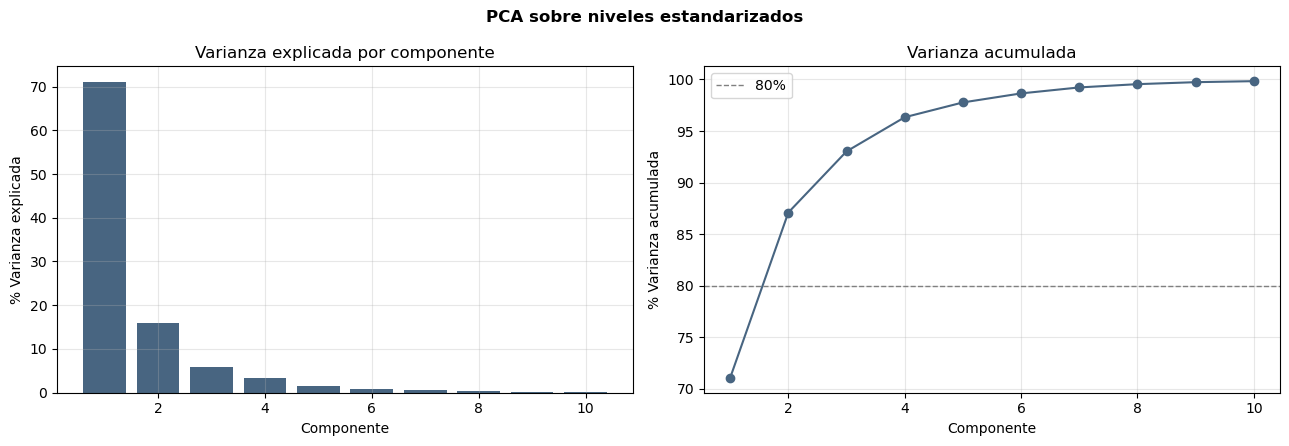

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

n_mostrar = min(10, len(pca_niveles.explained_variance_ratio_))
var_exp = pca_niveles.explained_variance_ratio_[:n_mostrar] * 100
var_acum = np.cumsum(pca_niveles.explained_variance_ratio_[:n_mostrar]) * 100

axes[0].bar(range(1, n_mostrar + 1), var_exp, color='#486581')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('% Varianza explicada')
axes[0].set_title('Varianza explicada por componente')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, n_mostrar + 1), var_acum, marker='o', color='#486581')
axes[1].axhline(80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('% Varianza acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA sobre niveles estandarizados', fontsize=12, fontweight='bold')
plt.tight_layout()
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/05_pca_scree_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Cargas factoriales — primeros 3 componentes (niveles)

Las variables con mayor carga (en valor absoluto) en cada componente son las
que ese componente resume. Sirve para la lectura económica de cada PC.

In [5]:
for pc in ['PC1', 'PC2', 'PC3']:
    print(f'--- {pc} (niveles) — variables con mayor carga ---')
    print(cargas_niveles[pc].abs().sort_values(ascending=False).head(6).round(3))
    print()

--- PC1 (niveles) — variables con mayor carga ---
Crédito hipotecario          1.001
Liquidez M3                  0.997
Crédito SF sector privado    0.997
Liquidez M2                  0.995
Crédito empresarial          0.994
Crédito consumo              0.984
Name: PC1, dtype: float64

--- PC2 (niveles) — variables con mayor carga ---
Tasa interbancaria      0.983
Tasa referencia BCRP    0.980
Tasa pasiva TIPMN       0.921
Tasa activa TAMN        0.400
embi_peru               0.382
IPC Lima                0.222
Name: PC2, dtype: float64

--- PC3 (niveles) — variables con mayor carga ---
embi_peru                   0.768
Índice BVL                  0.531
Tipo de cambio              0.439
Tasa activa TAMN            0.167
Reservas internacionales    0.138
Crédito empresarial         0.120
Name: PC3, dtype: float64



### 3.3 Biplot (PC1 vs PC2) — niveles

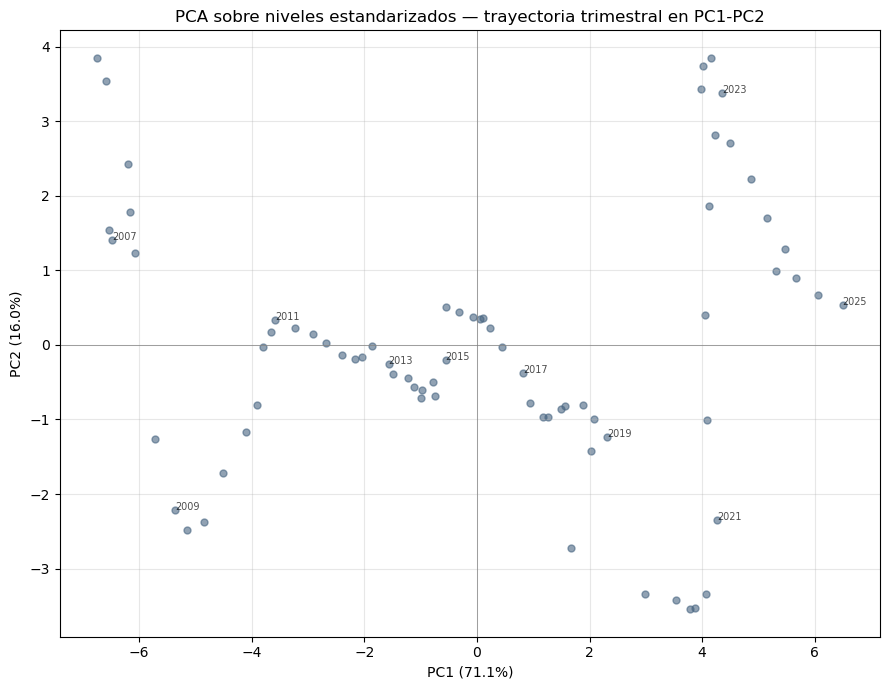

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(scores_niveles['PC1'], scores_niveles['PC2'], alpha=0.6, s=25, color='#486581')

for i, fecha in enumerate(scores_niveles.index):
    if i % 8 == 0:  # etiquetar cada 2 años (trimestral) para no saturar el grafico
        ax.annotate(fecha.strftime('%Y'), (scores_niveles['PC1'].iloc[i], scores_niveles['PC2'].iloc[i]),
                    fontsize=7, alpha=0.7)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_niveles.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_niveles.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA sobre niveles estandarizados — trayectoria trimestral en PC1-PC2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/05_pca_biplot_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Diagnóstico de tendencia común (niveles)

Verificación explícita del riesgo señalado en la discusión metodológica:
si PC1 correlaciona fuertemente con el simple paso del tiempo, es señal de
que el componente está capturando tendencia común, no estructura económica.

In [7]:
indice_temporal = np.arange(len(scores_niveles))
corr_pc1_tiempo = np.corrcoef(scores_niveles['PC1'], indice_temporal)[0, 1]
print(f'Correlación entre PC1 y el paso del tiempo (niveles): {corr_pc1_tiempo:.3f}')
if abs(corr_pc1_tiempo) > 0.7:
    print('⚠ Correlación alta: PC1 podría estar dominado por tendencia común, no por')
    print('  estructura de co-movimiento economicamente interesante. Interpretar con cautela.')
else:
    print('Correlación moderada/baja: PC1 no parece dominado por una tendencia temporal simple.')

Correlación entre PC1 y el paso del tiempo (niveles): 0.994
⚠ Correlación alta: PC1 podría estar dominado por tendencia común, no por
  estructura de co-movimiento economicamente interesante. Interpretar con cautela.


## 4. PCA sobre datos transformados y estandarizados (log-diff / diff)

In [8]:
pca_transf, scores_transf, cargas_transf = ajustar_pca(df_transf, 'transformado estandarizado')

--- PCA sobre transformado estandarizado ---
Componentes retenidos: 18
Varianza explicada (primeros 5): [30.4 16.7 14.5  9.7  6.1]%
Varianza acumulada (primeros 5): [30.4 47.2 61.6 71.4 77.5]%


### 4.1 Scree plot (transformado)

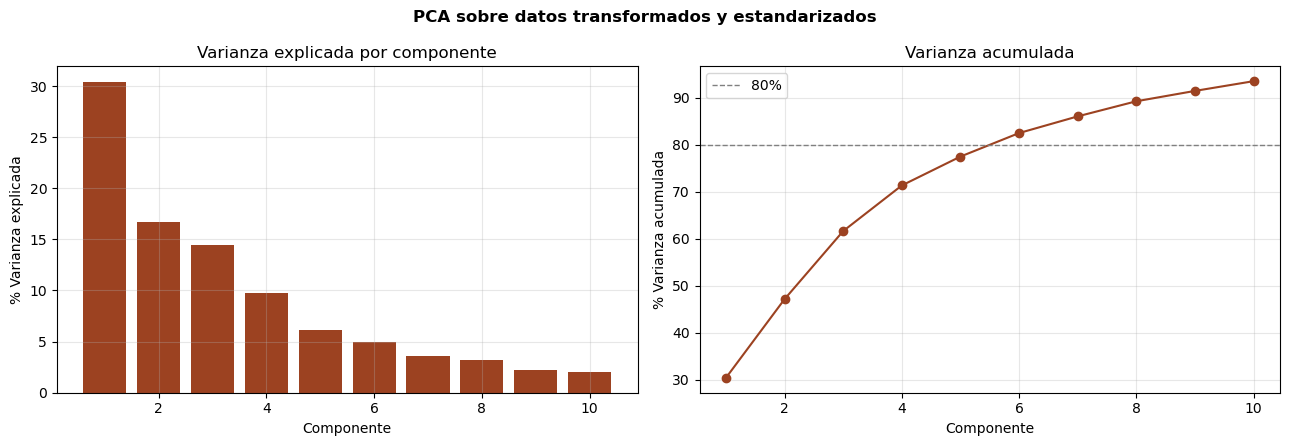

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

n_mostrar = min(10, len(pca_transf.explained_variance_ratio_))
var_exp = pca_transf.explained_variance_ratio_[:n_mostrar] * 100
var_acum = np.cumsum(pca_transf.explained_variance_ratio_[:n_mostrar]) * 100

axes[0].bar(range(1, n_mostrar + 1), var_exp, color='#9c4221')
axes[0].set_xlabel('Componente')
axes[0].set_ylabel('% Varianza explicada')
axes[0].set_title('Varianza explicada por componente')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, n_mostrar + 1), var_acum, marker='o', color='#9c4221')
axes[1].axhline(80, color='gray', linestyle='--', linewidth=1, label='80%')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('% Varianza acumulada')
axes[1].set_title('Varianza acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA sobre datos transformados y estandarizados', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/05_pca_scree_transformado.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Cargas factoriales — primeros 3 componentes (transformado)

In [10]:
for pc in ['PC1', 'PC2', 'PC3']:
    print(f'--- {pc} (transformado) — variables con mayor carga ---')
    print(cargas_transf[pc].abs().sort_values(ascending=False).head(6).round(3))
    print()

--- PC1 (transformado) — variables con mayor carga ---
Tasa pasiva TIPMN_diff       0.831
Liquidez M2_log_diff         0.822
Tasa interbancaria_diff      0.820
Tasa referencia BCRP_diff    0.804
IPC Lima_log_diff            0.788
Liquidez M3_log_diff         0.773
Name: PC1, dtype: float64

--- PC2 (transformado) — variables con mayor carga ---
Crédito consumo_log_diff             0.683
Reservas internacionales_log_diff    0.627
Tipo de cambio_log_diff              0.535
indice_precios_inmuebles_log_diff    0.517
Liquidez M2_log_diff                 0.492
Crédito hipotecario_log_diff         0.452
Name: PC2, dtype: float64

--- PC3 (transformado) — variables con mayor carga ---
Crédito empresarial_log_diff         0.858
Índice BVL_log_diff                  0.598
Crédito hipotecario_log_diff         0.577
Liquidez M1_log_diff                 0.567
embi_peru_diff                       0.542
indice_precios_inmuebles_log_diff    0.512
Name: PC3, dtype: float64



### 4.3 Biplot (PC1 vs PC2) — transformado

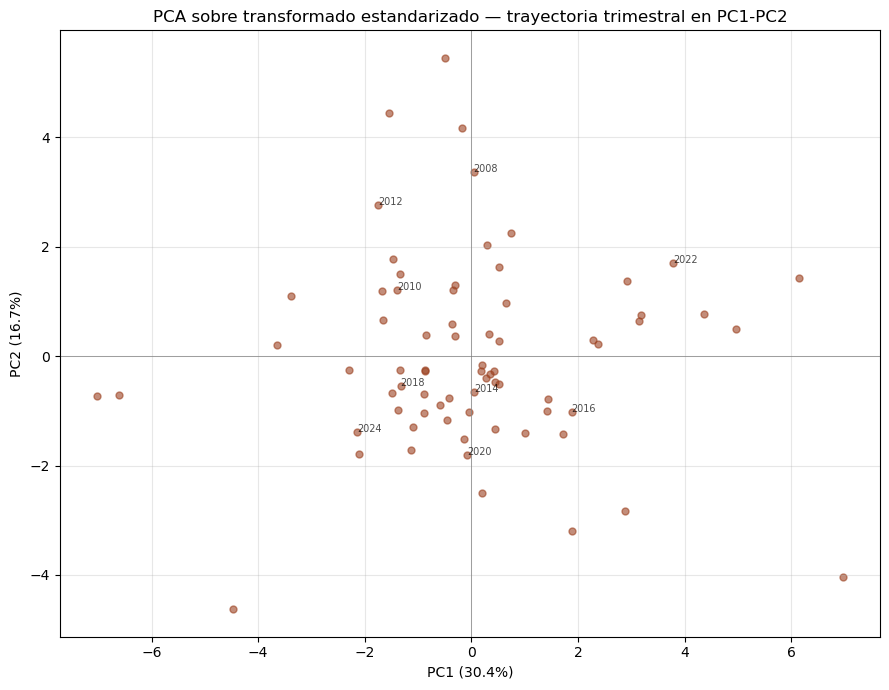

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(scores_transf['PC1'], scores_transf['PC2'], alpha=0.6, s=25, color='#9c4221')

for i, fecha in enumerate(scores_transf.index):
    if i % 8 == 0:
        ax.annotate(fecha.strftime('%Y'), (scores_transf['PC1'].iloc[i], scores_transf['PC2'].iloc[i]),
                    fontsize=7, alpha=0.7)

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca_transf.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_transf.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA sobre transformado estandarizado — trayectoria trimestral en PC1-PC2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/figures/05_pca_biplot_transformado.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Diagnóstico de tendencia común (transformado)

In [12]:
indice_temporal = np.arange(len(scores_transf))
corr_pc1_tiempo = np.corrcoef(scores_transf['PC1'], indice_temporal)[0, 1]
print(f'Correlación entre PC1 y el paso del tiempo (transformado): {corr_pc1_tiempo:.3f}')
if abs(corr_pc1_tiempo) > 0.7:
    print('⚠ Correlación alta: revisar.')
else:
    print('Correlación moderada/baja: PC1 no parece dominado por tendencia temporal simple.')

Correlación entre PC1 y el paso del tiempo (transformado): 0.089
Correlación moderada/baja: PC1 no parece dominado por tendencia temporal simple.


## 5. Comparación directa: niveles vs. transformado

Tabla resumen para el capítulo de validación (sección 6 del marco
conceptual): capacidad descriptiva (varianza explicada) e indicio de
contaminación por tendencia (correlación PC1-tiempo).

In [13]:
comparacion = pd.DataFrame({
    'Métrica': [
        'Varianza explicada PC1 (%)',
        'Varianza explicada PC2 (%)',
        'Varianza acumulada 3 PCs (%)',
        'Componentes para 80% varianza',
        'Correlación PC1 vs. tiempo',
    ],
    'Niveles estandarizados': [
        round(pca_niveles.explained_variance_ratio_[0] * 100, 1),
        round(pca_niveles.explained_variance_ratio_[1] * 100, 1),
        round(np.cumsum(pca_niveles.explained_variance_ratio_[:3])[-1] * 100, 1),
        int(np.argmax(np.cumsum(pca_niveles.explained_variance_ratio_) >= 0.80) + 1),
        round(np.corrcoef(scores_niveles['PC1'], np.arange(len(scores_niveles)))[0, 1], 3),
    ],
    'Transformado estandarizado': [
        round(pca_transf.explained_variance_ratio_[0] * 100, 1),
        round(pca_transf.explained_variance_ratio_[1] * 100, 1),
        round(np.cumsum(pca_transf.explained_variance_ratio_[:3])[-1] * 100, 1),
        int(np.argmax(np.cumsum(pca_transf.explained_variance_ratio_) >= 0.80) + 1),
        round(np.corrcoef(scores_transf['PC1'], np.arange(len(scores_transf)))[0, 1], 3),
    ],
})
comparacion

,Métrica,Niveles estandarizados,Transformado estandarizado
0,Varianza explicada PC1 (%),71.100,30.400
1,Varianza explicada PC2 (%),16.000,16.700
2,Varianza acumulada 3 PCs (%),93.000,61.600
3,Componentes para 80% varianza,2.000,6.000
4,Correlación PC1 vs. tiempo,0.994,0.089


## 6. Guardar resultados

Se guardan scores, cargas y la tabla comparativa. Ninguno de estos archivos
sobrescribe `data/processed/` -- son resultados derivados, en `data/results/`.

In [14]:
os.makedirs('data/results', exist_ok=True)

scores_niveles.to_csv('data/results/05_pca_scores_niveles.csv')
scores_transf.to_csv('data/results/05_pca_scores_transformado.csv')
cargas_niveles.to_csv('data/results/05_pca_cargas_niveles.csv')
cargas_transf.to_csv('data/results/05_pca_cargas_transformado.csv')
comparacion.to_csv('data/results/05_pca_comparacion.csv', index=False)

print('Resultados guardados en data/results/:')
print('  - 05_pca_scores_niveles.csv / 05_pca_scores_transformado.csv')
print('  - 05_pca_cargas_niveles.csv / 05_pca_cargas_transformado.csv')
print('  - 05_pca_comparacion.csv')

Resultados guardados en data/results/:
  - 05_pca_scores_niveles.csv / 05_pca_scores_transformado.csv
  - 05_pca_cargas_niveles.csv / 05_pca_cargas_transformado.csv
  - 05_pca_comparacion.csv


In [15]:
for pc in ['PC1', 'PC2', 'PC3']:
    corr = np.corrcoef(scores_niveles[pc], np.arange(len(scores_niveles)))[0, 1]
    print(f'Correlación {pc} vs. tiempo (niveles): {corr:.3f}')

Correlación PC1 vs. tiempo (niveles): 0.994
Correlación PC2 vs. tiempo (niveles): 0.068
Correlación PC3 vs. tiempo (niveles): 0.036
